
#### Análisis ConnectaTel


Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [3]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:

# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')


In [5]:

# mostrar las primeras 5 filas de plans
plans.head()


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [6]:


# mostrar las primeras 5 filas de users
users.head()



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [7]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [8]:

# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)


plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [9]:
# inspección de plans con .info()
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [10]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [11]:

# inspección de usage con .info()
usage.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [12]:
# cantidad de nulos para users
print("Cantidad de valores nulos:")
print(users.isna().sum())
print("-" * 30)

Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
------------------------------


In [13]:
# cantidad de nulos para usage
print("Cantidad de valores nulos en USAGE:")
print(usage.isna().sum())

print("-" * 30)

Cantidad de valores nulos en USAGE:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
------------------------------


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [14]:

# explorar columnas numéricas de users
print("Resumen estadístico de usuarios:")
display(users.describe())


Resumen estadístico de usuarios:


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` La columna user_id no presenta problemas, ya que sus valores son únicos, consecutivos y están dentro de un rango lógico (10000 a 13999). No requiere limpieza ni transformación, por lo que puede utilizarse como identificador confiable de los usuarios.
- La columna `age` La columna age presenta un problema importante de calidad de datos. Se observa un valor mínimo de -999, lo cual es imposible para una edad y sugiere la presencia de un valor sentinel utilizado para representar datos faltantes o errores de captura. Además, el alto valor de la desviación estándar (123) confirma la existencia de valores atípicos que distorsionan la distribución.

Se recomienda reemplazar estos valores por NaN para posteriormente analizarlos o imputarlos, ya que afectan el cálculo de estadísticas y segmentaciones por edad.

In [15]:

# explorar columnas numéricas de usage
print("Resumen estadístico de uso (llamadas y mensajes):")
display(usage.describe())


Resumen estadístico de uso (llamadas y mensajes):


,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`La columna id funciona como identificador único de cada registro de uso y no presenta inconsistencias, ya que sus valores son consecutivos dentro del rango esperado (1 a 40000).

Por su parte, la columna user_id también se encuentra dentro de un rango lógico (10000 a 13999) y permite relacionar correctamente la información con el dataset de usuarios. Ambas columnas no requieren limpieza y pueden utilizarse sin modificaciones.
- Las columnas duration y lenght Las columnas duration (duración de llamadas) y length (longitud de mensajes) presentan valores faltantes, lo cual es esperado debido a la naturaleza del dataset:

duration solo aplica para registros de tipo llamada (call)
length solo aplica para registros de tipo mensaje (text)

Se observa que los valores mínimos son 0, lo que podría representar llamadas muy cortas o mensajes vacíos, aunque también podría indicar posibles inconsistencias que requieren validación adicional.

En cuanto a los valores máximos, se identifican posibles valores atípicos:

Duraciones de hasta 120 minutos
Longitudes de mensajes de hasta 1490 caracteres

Estos valores extremos podrían representar comportamientos reales de usuarios intensivos o posibles anomalías, por lo que deben analizarse en la etapa de detección de outliers.

In [16]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"Valores únicos en la columna '{col}':")
    print(users[col].unique())
    print(f"\nConteo de valores para '{col}':")
    print(users[col].value_counts())
    print("-" * 30)


Valores únicos en la columna 'city':
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Conteo de valores para 'city':
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
------------------------------
Valores únicos en la columna 'plan':
['Basico' 'Premium']

Conteo de valores para 'plan':
Basico     2595
Premium    1405
Name: plan, dtype: int64
------------------------------


- La columna `city` La columna city presenta problemas de calidad de datos. Se identifican valores faltantes (NaN) y valores inválidos representados con el símbolo "?", lo cual indica un uso inconsistente de sentinels para datos desconocidos.

En términos de proporción, existen 469 valores nulos y 96 registros con "?", lo que representa aproximadamente el 14% del total de los datos, un porcentaje relevante que puede afectar análisis geográficos o segmentaciones por ciudad.

Se recomienda reemplazar "?" por NaN para unificar el tratamiento de valores faltantes y posteriormente evaluar si imputarlos o excluirlos dependiendo del análisis.
- La columna `plan` La columna plan no presenta problemas de calidad. Contiene únicamente dos categorías válidas: Basico y Premium, con una distribución donde predomina el plan Basico (~65%) frente al Premium (~35%).

Esta variable es consistente y será clave para analizar diferencias en el comportamiento de uso entre tipos de plan.

In [17]:



# explorar columna categórica de usage
usage['type'] # completa el código
print("Valores únicos en 'type':")
print(usage['type'].unique())

print("\nDistribución de tipos de uso:")
print(usage['type'].value_counts())



Valores únicos en 'type':
['call' 'text']

Distribución de tipos de uso:
text    22092
call    17908
Name: type, dtype: int64


- La columna `type`La columna type no presenta problemas de calidad de datos. Contiene únicamente dos categorías válidas: call y text, que representan los tipos de uso del servicio (llamadas y mensajes).

La distribución muestra una ligera predominancia de los mensajes (text) con 22,092 registros frente a 17,908 de llamadas (call), lo que indica que los usuarios tienden a utilizar más el servicio de mensajería que las llamadas.

Esta variable es consistente y será fundamental para diferenciar el análisis entre tipos de uso, así como para interpretar correctamente los valores nulos en las columnas duration y length.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

Durante la exploración de los datos se identificaron valores inválidos (sentinels) en distintas columnas que pueden afectar el análisis si no se corrigen.

Columna age

Se detectó el valor -999, el cual es un valor imposible para la edad de un usuario y claramente representa un sentinel utilizado para indicar datos faltantes o errores de captura.

Acción recomendada: Reemplazar estos valores por NaN para evitar distorsiones en el análisis estadístico y en la segmentación por edad.

Columna city

Se identificó el valor "?", el cual representa un dato desconocido y funciona como sentinel. Además, la columna ya contiene valores nulos (NaN), lo que evidencia inconsistencia en la forma de registrar datos faltantes.

Acción recomendada: Reemplazar "?" por NaN para estandarizar los valores faltantes y facilitar su tratamiento posterior.

Columnas duration y length

Aunque contienen valores nulos, estos no representan necesariamente un problema de calidad, sino una característica del dataset, ya que:

duration aplica únicamente a llamadas (call)
length aplica únicamente a mensajes (text)

Sin embargo, se observan valores mínimos de 0, los cuales podrían representar registros válidos (llamadas muy cortas o mensajes vacíos) o posibles inconsistencias.

Acción recomendada: Validar si estos valores son coherentes con la lógica del negocio y decidir si deben mantenerse o tratarse como valores atípicos en etapas posteriores.

La presencia de sentinels y valores inconsistentes en columnas clave como edad y ciudad puede sesgar significativamente los análisis si no se corrigen. Por ello, es fundamental estandarizar los valores faltantes antes de avanzar hacia la limpieza y segmentación de los datos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [53]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [54]:


# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')



In [55]:
# Revisar los años presentes en `reg_date` de users
print("Distribución de años en 'reg_date':")
print(users['reg_date'].dt.year.value_counts().sort_index())


Distribución de años en 'reg_date':
2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64


En `reg_date` La columna reg_date fue convertida correctamente al tipo fecha sin generar errores, lo que indica que el formato original era consistente o que los valores inválidos fueron manejados adecuadamente con errors='coerce'.

Al analizar la distribución de los años, se observa que todos los registros se encuentran dentro del rango esperado (2022, 2023 y 2024), lo cual es coherente con el contexto del negocio, ya que se indicó que los datos están registrados hasta 2024.

No se identifican fechas futuras ni valores fuera de rango, por lo que la columna no requiere limpieza adicional y puede utilizarse de forma confiable para análisis temporales.

La correcta distribución temporal de los datos permite analizar la evolución del comportamiento de los usuarios a lo largo del tiempo sin riesgo de sesgos por errores en fechas.

In [56]:


# Revisar los años presentes en `date` de usage
print("Distribución de años en 'date' (Usage):")
print(usage['date'].dt.year.value_counts().sort_index())



Distribución de años en 'date' (Usage):
2024.0    39950
Name: date, dtype: int64



En `date` La columna date fue convertida correctamente al tipo fecha, y al analizar la distribución de los años se observa que todos los registros corresponden únicamente al año 2024.

Esto es consistente con el contexto del análisis, ya que se indicó que los datos de uso están registrados hasta este año. No se identifican fechas fuera de rango ni valores futuros, lo que confirma la integridad temporal del dataset.

Asimismo, la diferencia entre el total de registros (40000) y los valores con fecha válida (39950) indica la presencia de un número reducido de valores nulos, los cuales probablemente fueron generados durante la conversión con errors='coerce'.

Dado que todos los datos de uso corresponden al año 2024 y no presentan inconsistencias temporales, se puede basar el análisis en este periodo sin necesidad de realizar ajustes adicionales en esta columna.


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

Durante la revisión de las columnas de fecha (reg_date en users y date en usage), no se identificaron años fuera de rango ni valores imposibles.

En el caso de reg_date, los registros se encuentran entre los años 2022 y 2024, lo cual es coherente con el contexto del negocio. Por otro lado, la columna date del dataset de uso contiene únicamente registros del año 2024, sin presencia de fechas futuras o inválidas.

No se detectaron años extremadamente antiguos ni posteriores al periodo de análisis, por lo que no hay evidencia de errores de captura relacionados con fechas.

La consistencia en las fechas permite realizar análisis temporales confiables, como tendencias de uso o comportamiento por periodo, sin riesgo de sesgos por errores en los datos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:

import pandas as pd

# Reemplazar ? por NA en city
users.loc[users['city'] == "?", "city"] = pd.NA

# Verificar cambios
print(f"Valores únicos tras la limpieza: {users['city'].unique()}")

print(f"Cantidad de nulos detectados: {users['city'].isna().sum()}")

Valores únicos tras la limpieza: ['Medellín' <NA> 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
Cantidad de nulos detectados: 565


In [24]:
import numpy as np
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = np.nan

# Verificar cambios
print("Conteo de años después de la limpieza:")
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

print(f"\nTotal de valores nulos (NaT) en reg_date: {users['reg_date'].isna().sum()}")

Conteo de años después de la limpieza:
2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

Total de valores nulos (NaT) en reg_date: 40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [25]:

# Verificación MAR en usage (Missing At Random) para duration
mar_duration = usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())

print("Conteo de nulos en 'duration' por tipo de uso:")
print(mar_duration)


Conteo de nulos en 'duration' por tipo de uso:
type
call        0
text    22076
Name: duration, dtype: int64


In [26]:
# Verificación MAR en usage (Missing At Random) para length
# Agrupamos por 'type' y contamos cuántos nulos hay en 'length'
nulos_por_tipo_length = usage.groupby('type')['length'].apply(lambda x: x.isna().sum())

print("Conteo de nulos en 'length' por tipo de uso:")
print(nulos_por_tipo_length)

# Proporción de nulos para mayor claridad
print("\nProporción de nulos en 'length' por tipo:")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean()))

Conteo de nulos en 'length' por tipo de uso:
type
call    17896
text        0
Name: length, dtype: int64

Proporción de nulos en 'length' por tipo:
type
call    0.99933
text    0.00000
Name: length, dtype: float64


Al analizar los valores nulos en las columnas duration y length, se observa que estos no ocurren de manera aleatoria, sino que dependen directamente de la variable type.

En particular:

La columna duration presenta valores nulos únicamente cuando el tipo de registro es text, lo cual es lógico ya que los mensajes no tienen duración.
La columna length presenta valores nulos únicamente cuando el tipo de registro es call, ya que las llamadas no tienen longitud de mensaje.

Este comportamiento confirma que los valores nulos son del tipo MAR (Missing At Random), ya que dependen de otra variable observada (type) y no representan errores de captura ni inconsistencias en los datos.

La correcta identificación de estos nulos como estructurales evita manipulaciones innecesarias de los datos y permite realizar un análisis más preciso del comportamiento de los usuarios según el tipo de servicio utilizado.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [27]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas
    
    
# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
'is_text': 'sum',
'is_call': 'sum',
'duration': 'sum'
}).reset_index()

# Renombrar columnas para claridad (Paso sugerido por las instrucciones)
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# observar resultado
usage_agg.head(3)
    



,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

# Los usuarios sin consumo aparecerán con NaN. 
# Los convertimos a 0 para poder realizar cálculos matemáticos.
cols_uso = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[cols_uso] = user_profile[cols_uso].fillna(0)

user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [30]:
# Resumen estadístico de las columnas numéricas
# 1. Seleccionamos las columnas numéricas relevantes
cols_interes = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# 2. Generamos el resumen estadístico
# .T transpone la tabla (las métricas pasan a ser columnas y las variables a filas)
resumen_stats = user_profile[cols_interes].describe().T

# 3. Agregamos la mediana explícitamente (aunque es el '50%', tenerla aparte ayuda)
resumen_stats['median'] = user_profile[cols_interes].median()

# Mostrar resultado con formato limpio
print("Resumen Estadístico del Comportamiento de Usuarios:")
display(resumen_stats[['count', 'mean', 'median', 'std', 'min', 'max']])

Resumen Estadístico del Comportamiento de Usuarios:


,count,mean,median,std,min,max
age,4000.0,48.136000,48.00,17.689919,18.0,79.00
cant_mensajes,4000.0,5.523000,5.00,2.359738,0.0,17.00
cant_llamadas,4000.0,4.477000,4.00,2.145139,0.0,15.00
cant_minutos_llamada,4000.0,23.311225,19.78,18.169564,0.0,155.69


In [31]:
# Distribución porcentual del tipo de plan
# Calcular la distribución porcentual de la columna 'plan'
plan_distribucion = user_profile['plan'].value_counts(normalize=True) * 100

# Mostrar el resultado con un formato amigable
print("Distribución porcentual por tipo de plan:")
print(plan_distribucion.map("{:.2f}%".format))

# Opcional: Si quieres ver también las cantidades absolutas junto a los porcentajes
resumen_plan = pd.DataFrame({
    'Cantidad': user_profile['plan'].value_counts(),
    'Porcentaje': plan_distribucion.map("{:.2f}%".format)
})
print("\nTabla resumen de planes:")
display(resumen_plan)


Distribución porcentual por tipo de plan:
Basico     64.88%
Premium    35.12%
Name: plan, dtype: object

Tabla resumen de planes:


,Cantidad,Porcentaje
Basico,2595,64.88%
Premium,1405,35.12%


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

<AxesSubplot:xlabel='age', ylabel='Count'>

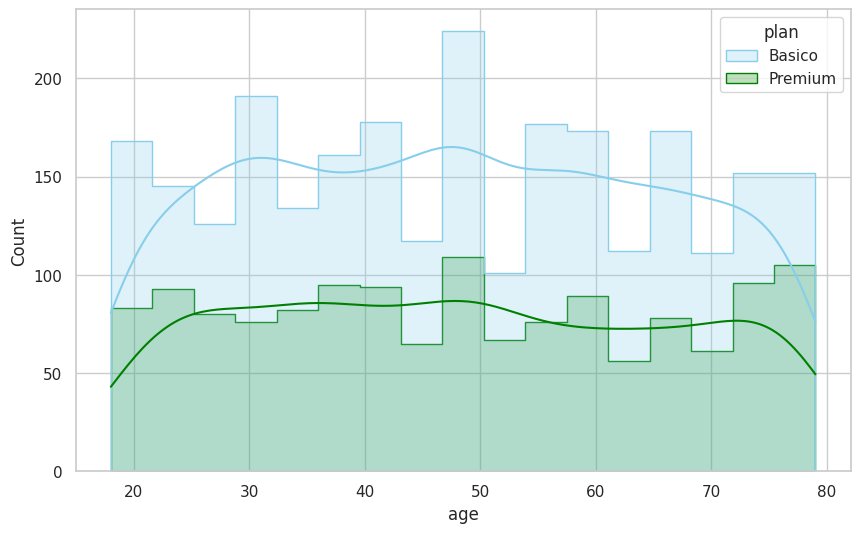

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración de estilo
sns.set_theme(style="whitegrid")


# Histograma para visualizar la edad (age)

plt.figure(figsize=(10, 6))
sns.histplot(
    data=user_profile, 
    x='age', 
    hue='plan', 
    element='step', 
    palette=['skyblue', 'green'], 
    kde=True
)



💡Insights: 
- Distribución
La distribución de la edad de los usuarios muestra una forma relativamente uniforme, con una ligera concentración en edades medias (alrededor de los 30 a 60 años). No se observa un sesgo pronunciado hacia edades jóvenes o mayores, lo que indica una base de clientes diversa en términos de edad.

Al comparar por tipo de plan, no se identifican diferencias significativas entre usuarios de Básico y Premium, ya que ambos planes presentan distribuciones similares a lo largo de todos los rangos de edad. Esto sugiere que la elección del plan no está fuertemente influenciada por la edad del usuario.

La distribución puede considerarse ligeramente simétrica, sin presencia de outliers evidentes, lo que indica que los datos de edad han sido correctamente limpiados y no presentan valores extremos que distorsionen el análisis.

La ausencia de diferencias claras por edad entre planes sugiere que la segmentación actual de productos no está adaptada a grupos etarios específicos, lo que representa una oportunidad para diseñar ofertas más personalizadas según el perfil demográfico.
  

<AxesSubplot:xlabel='cant_mensajes', ylabel='Count'>

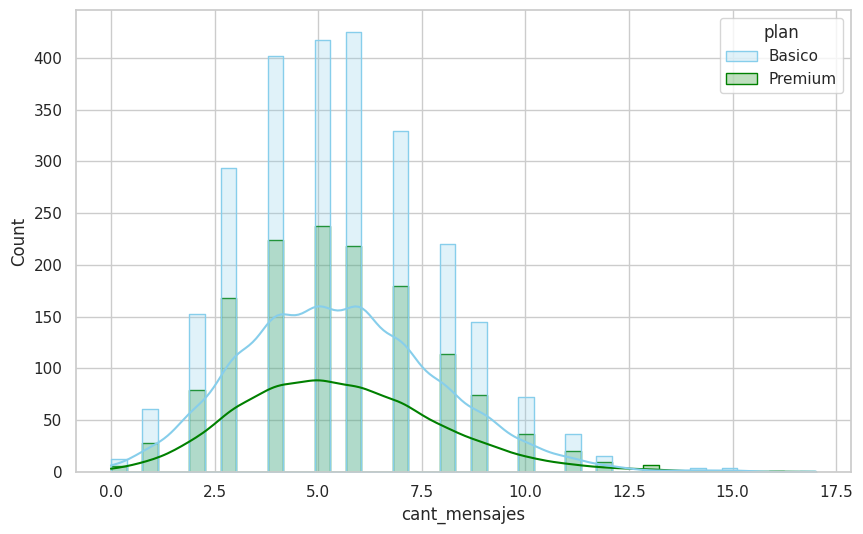

In [33]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10, 6))
sns.histplot(
    data=user_profile, 
    x='cant_mensajes', 
    hue='plan', 
    element='step', 
    palette=['skyblue', 'green'], 
    kde=True
)

💡Insights: 
La distribución del número de mensajes muestra una ligera asimetría hacia la derecha (sesgo positivo), lo que indica que la mayoría de los usuarios envía una cantidad moderada de mensajes (alrededor de 4 a 7), mientras que pocos usuarios presentan valores altos.

Al comparar por tipo de plan, se observa que los usuarios del plan Básico concentran una mayor frecuencia en casi todos los rangos de mensajes, lo cual es consistente con su mayor proporción dentro de la base de usuarios. Sin embargo, los usuarios del plan Premium tienden a tener una presencia relativamente mayor en los valores más altos de mensajes, lo que sugiere un comportamiento de uso más intensivo.

También se identifican algunos valores altos (hasta aproximadamente 17 mensajes), que podrían considerarse usuarios intensivos, aunque no parecen ser outliers extremos, sino parte natural de la distribución.

El hecho de que los usuarios Premium tiendan a concentrarse en niveles más altos de uso de mensajería sugiere que este segmento podría estar aprovechando mejor los beneficios del plan, lo que refuerza la lógica de segmentación actual pero también abre la oportunidad de incentivar la migración de usuarios Básicos con alto uso hacia planes superiores.

<AxesSubplot:xlabel='cant_llamadas', ylabel='Count'>

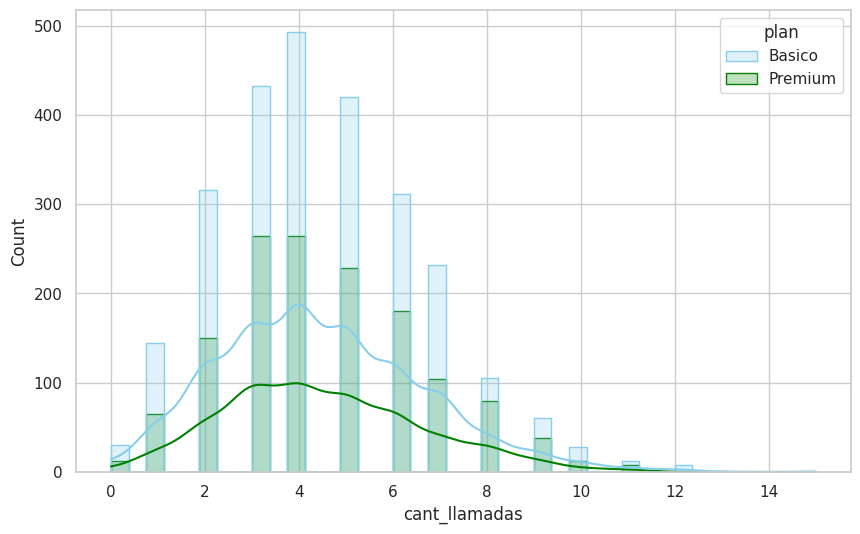

In [34]:

# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 6))
sns.histplot(
    data=user_profile, 
    x='cant_llamadas', 
    hue='plan', 
    element='step', 
    palette=['skyblue', 'green'], 
    kde=True
)


💡Insights: 
- Distribución

La distribución del número de llamadas presenta una asimetría hacia la derecha (sesgo positivo), donde la mayoría de los usuarios realiza entre 2 y 6 llamadas, mientras que un número menor de usuarios alcanza valores más altos.

Al comparar por tipo de plan, se observa que los usuarios del plan Básico concentran la mayor cantidad de registros en todos los rangos, lo cual es consistente con su mayor proporción en la base de clientes. Sin embargo, los usuarios del plan Premium muestran una ligera mayor presencia relativa en los rangos superiores de llamadas, lo que sugiere un comportamiento de uso más intensivo.

Se identifican valores máximos cercanos a 15 llamadas, que podrían considerarse usuarios de alto uso, aunque no representan outliers extremos, sino casos dentro del comportamiento esperado.

El patrón observado indica que, aunque la mayoría de los usuarios tiene un uso moderado del servicio de llamadas, existe un segmento que realiza un mayor número de llamadas y que podría beneficiarse de planes con mayores beneficios o incentivos para incrementar su consumo.

<AxesSubplot:xlabel='cant_minutos_llamada', ylabel='Count'>

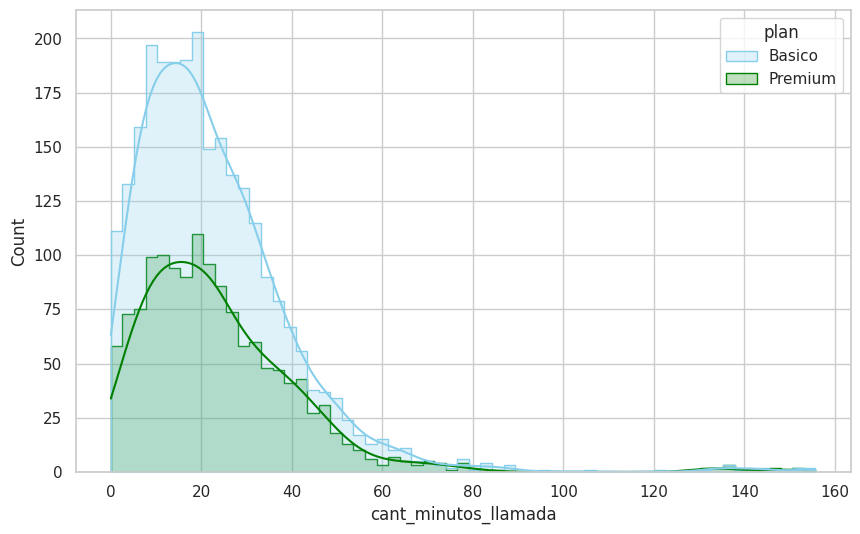

In [35]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 6))
sns.histplot(
    data=user_profile, 
    x='cant_minutos_llamada', 
    hue='plan', 
    element='step', 
    palette=['skyblue', 'green'], 
    kde=True
)

💡Insights: 
La distribución de los minutos de llamadas presenta una fuerte asimetría hacia la derecha (sesgo positivo), lo que indica que la mayoría de los usuarios consume pocos minutos (principalmente entre 5 y 30), mientras que un grupo reducido presenta consumos muy elevados.

Al comparar por tipo de plan, se observa que los usuarios del plan Premium tienden a concentrarse ligeramente más en rangos de mayor consumo de minutos, lo que sugiere que este segmento hace un uso más intensivo del servicio de llamadas. Sin embargo, también se identifica que muchos usuarios del plan Básico alcanzan niveles relativamente altos de consumo, lo que podría indicar un posible desajuste entre el plan contratado y sus necesidades reales.

Se identifican valores extremos que superan los 100 minutos, llegando incluso a más de 150 minutos, lo que representa posibles outliers o usuarios altamente intensivos. Estos casos pueden ser clave para identificar oportunidades de segmentación o detección de comportamientos atípicos.

La presencia de usuarios del plan Básico con altos niveles de consumo de minutos sugiere una oportunidad clara de upselling hacia planes Premium, mientras que los usuarios Premium con alto consumo confirman la efectividad del plan para capturar clientes de alto valor.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

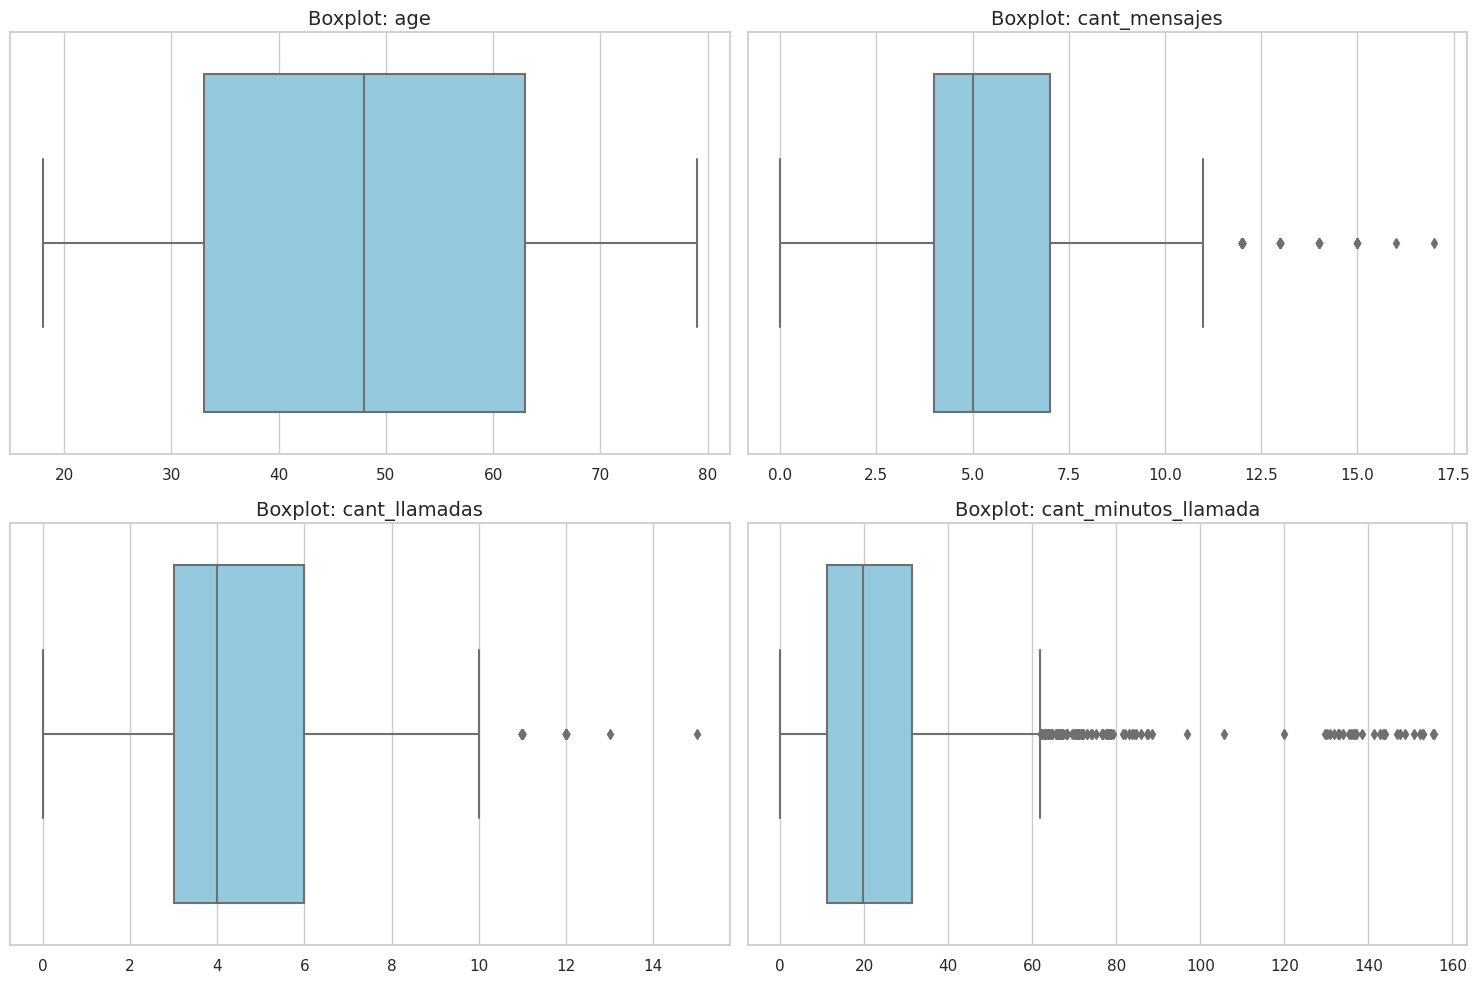

In [36]:
# Visualizando usando BoxPlot 
import matplotlib.pyplot as plt
import seaborn as sns

# Definir las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Configurar el lienzo (layout de 2 filas y 2 columnas)
plt.figure(figsize=(15, 10))

for i, col in enumerate(columnas_numericas):
    plt.subplot(2, 2, i + 1)  # Posicionamiento en la cuadrícula
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}', fontsize=14)
    plt.xlabel('')  # Limpiar etiqueta eje X para evitar redundancia

plt.tight_layout()
plt.show()


💡Insights: 
- Age:No se observan outliers significativos. La distribución de edades se mantiene dentro de un rango lógico (18 a 79 años) y sin valores extremos fuera de los límites esperados. Esto indica que la limpieza previa (reemplazo de -999) fue efectiva.
- cant_mensajes: Sí se observan outliers en el extremo superior. Existen usuarios que envían una cantidad de mensajes considerablemente mayor (por encima de ~12), lo que indica un segmento de usuarios intensivos. Sin embargo, estos valores parecen coherentes con el comportamiento real y no necesariamente errores.
- cant_llamadas: También se identifican outliers en la parte superior (por encima de ~10 llamadas). Estos representan usuarios con alto nivel de uso. Al igual que en mensajes, no parecen errores, sino casos válidos de uso intensivo.
- cant_minutos_llamada: Se observan outliers claros y más pronunciados, especialmente en el extremo superior (más de 80–100 minutos). Este es el caso más relevante, ya que hay usuarios con consumos muy altos (hasta ~150 minutos), lo que indica comportamientos extremos o usuarios de alto valor.

In [37]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

print("--- Análisis de Límites Superiores (IQR) ---")

for col in columnas_limites:
    # 1. Calculamos los cuartiles Q1 (25%) y Q3 (75%)
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    
    # 2. Calculamos el IQR (Rango Intercuartílico)
    IQR = Q3 - Q1
    
    # 3. Definimos el límite superior (Q3 + 1.5 * IQR)
    limite_superior = Q3 + 1.5 * IQR
    
    # 4. Identificamos cuántos registros superan ese límite
    outliers = user_profile[user_profile[col] > limite_superior]
    
    print(f"\nVariable: {col}")
    print(f"  Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
    print(f"  Límite Superior Sugerido: {limite_superior:.2f}")
    print(f"  Cantidad de Outliers: {len(outliers)} ({len(outliers)/len(user_profile)*100:.2f}%)")


--- Análisis de Límites Superiores (IQR) ---

Variable: cant_mensajes
  Q1: 4.00 | Q3: 7.00 | IQR: 3.00
  Límite Superior Sugerido: 11.50
  Cantidad de Outliers: 46 (1.15%)

Variable: cant_llamadas
  Q1: 3.00 | Q3: 6.00 | IQR: 3.00
  Límite Superior Sugerido: 10.50
  Cantidad de Outliers: 30 (0.75%)

Variable: cant_minutos_llamada
  Q1: 11.11 | Q3: 31.41 | IQR: 20.30
  Límite Superior Sugerido: 61.87
  Cantidad de Outliers: 109 (2.73%)


In [38]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
# Mostrar el resumen estadístico para comparar
resumen = user_profile[columnas_limites].describe().T

# Calculamos el límite superior IQR para referencia visual en la misma tabla
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    resumen.loc[col, 'limite_iqr'] = Q3 + 1.5 * (Q3 - Q1)

print("Comparación de métricas vs Máximos:")
display(resumen[['mean', '50%', 'max', 'limite_iqr']])


Comparación de métricas vs Máximos:


,mean,50%,max,limite_iqr
cant_mensajes,5.523000,5.00,17.00,11.50
cant_llamadas,4.477000,4.00,15.00,10.50
cant_minutos_llamada,23.311225,19.78,155.69,61.87


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Se recomienda mantener los outliers.
El valor máximo (17) supera el límite IQR (11.5), pero la diferencia no es extrema y representa solo el 1.15% de los usuarios. Además, está relativamente cercano a la mediana (5), lo que indica que no son valores erróneos, sino casos de uso más intensivo.
- cant_llamadas: mantener o no outliers, porqué? Se recomienda mantener los outliers.
El máximo (15) supera el límite IQR (10.5), pero con una proporción aún menor (0.75%). Esto sugiere que estos usuarios simplemente realizan más llamadas que el promedio, sin representar anomalías o errores en los datos.
- cant_minutos_llamada: mantener o no outliers, porqué? Se recomienda mantener los outliers.
El máximo (15) supera el límite IQR (10.5), pero con una proporción aún menor (0.75%). Esto sugiere que estos usuarios simplemente realizan más llamadas que el promedio, sin representar anomalías o errores en los datos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [47]:
# Crear columna grupo_uso


import numpy as np

condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

opciones = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso')




In [48]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [49]:
# Crear columna grupo_edad

import numpy as np

condiciones = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]

opciones = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(condiciones, opciones, default='Adulto Mayor')

In [50]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

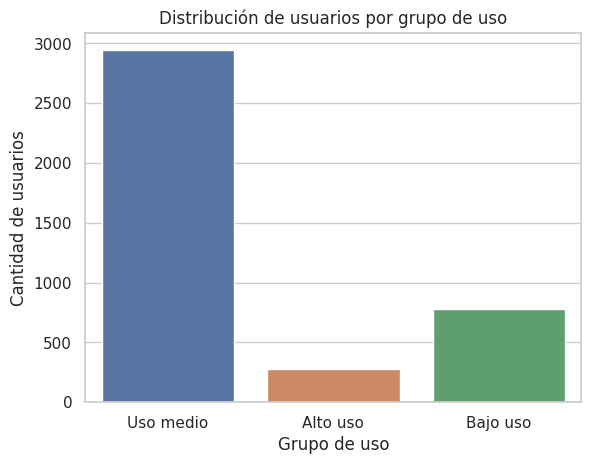

In [51]:

# Visualización de los segmentos por uso
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='grupo_uso', data=user_profile)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()


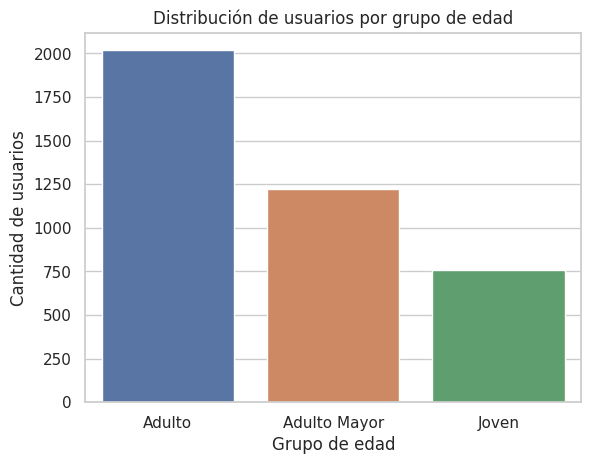

In [52]:
# Visualización de los segmentos por edad

sns.countplot(x='grupo_edad', data=user_profile)

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

Calidad de los datos

Durante la exploración inicial se identificaron varios problemas de calidad:

En la columna age, se detectaron valores inválidos como -999, los cuales fueron reemplazados por la mediana.
En la columna city, se encontraron valores inconsistentes como "?", que fueron convertidos a valores nulos. Esta columna presentó aproximadamente 565 valores nulos (~14%), lo que sugiere falta de captura en algunos registros.
En churn_date, se observaron muchos valores nulos (~88%), lo cual es esperado ya que representan usuarios activos.
En el dataset de uso (usage), los valores nulos en duration y length fueron identificados como estructurales (MAR), ya que dependen del tipo de evento (call o text), por lo que no requieren imputación.
Se detectaron 40 fechas fuera de rango en reg_date, las cuales fueron tratadas como nulas.

En general, los datos fueron limpiados correctamente y quedaron listos para análisis confiable.

Segmentación de clientes

Se identificaron dos tipos de segmentación:

Por nivel de uso:
Bajo uso: baja interacción en llamadas y mensajes
Uso medio: comportamiento promedio (segmento dominante)
Alto uso: usuarios intensivos
Por edad:
Jóvenes (<30 años)
Adultos (30–59 años) → segmento principal
Adulto Mayor (60+)

Se observó que la mayoría de los usuarios pertenece al grupo de Adultos con uso medio, lo que representa el comportamiento estándar del negocio.

Segmentos más valiosos

Los usuarios de Alto uso representan el segmento más valioso para ConnectaTel, ya que:

Tienen mayor consumo de servicios
Generan más ingresos (especialmente en minutos de llamada)
Presentan oportunidades claras de fidelización

Además, se identificó que algunos usuarios del plan Básico presentan niveles altos de uso, lo que indica una oportunidad de migración hacia planes Premium (upselling).

Patrones de uso extremo (Outliers)

Se detectaron outliers en todas las variables de uso, especialmente en:

cant_minutos_llamada (2.73%), con valores superiores a 100 minutos
cant_mensajes (1.15%)
cant_llamadas (0.75%)

Estos valores no representan errores, sino usuarios intensivos, lo cual implica:

Existencia de clientes de alto valor
Posible sobreconsumo en planes básicos
Oportunidad para diseñar planes más adecuados

Recomendaciones estratégicas
Optimización de planes (Upselling):
Identificar usuarios de alto uso en planes Básicos
Ofrecer migración a planes Premium con beneficios claros
Creación de planes segmentados:
Planes enfocados en alto consumo de llamadas
Planes específicos para usuarios de bajo uso (más económicos)
Estrategias por segmento de edad:
Ofertas digitales para usuarios jóvenes
Planes simplificados para adultos mayores
Activación de usuarios de bajo uso:
Campañas para incentivar el uso (bonos, promociones)
Notificaciones personalizadas
Monetización de usuarios intensivos:
Beneficios exclusivos para retención
Programas de lealtad

El análisis muestra que ConnectaTel cuenta con una base de usuarios diversa, donde la mayoría presenta un uso moderado, pero existe un segmento clave de usuarios intensivos que representa una oportunidad estratégica.

La empresa puede mejorar su rentabilidad y satisfacción del cliente mediante una segmentación más precisa y una oferta de planes adaptada al comportamiento real de uso.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Se identificaron valores inválidos en la columna age (ej. -999), los cuales fueron reemplazados por la mediana para evitar sesgos.
La columna city presentaba valores inconsistentes ("?") y aproximadamente 14% de datos faltantes, lo que indica problemas de captura.
En churn_date había cerca de 88% de valores nulos, lo cual es esperado al representar usuarios activos.
En el dataset de uso, los valores nulos en duration y length fueron identificados como estructurales (dependen del tipo de uso), por lo que no se consideran errores.
Se detectaron fechas fuera de rango (40 registros), las cuales fueron tratadas como nulas.


🔍 **Segmentos por Edad**
La mayoría de los usuarios pertenece al grupo de Adultos (30–59 años), siendo el segmento dominante.
Los jóvenes (<30) y adultos mayores (60+) representan una menor proporción dentro de la base.
Esto sugiere que el negocio está principalmente enfocado en usuarios adultos, con oportunidad de crecer en otros segmentos.


📊 **Segmentos por Nivel de Uso**
La mayor parte de los usuarios presenta un uso medio, lo que indica un comportamiento estable.
Existe un grupo relevante de bajo uso, que podría ser activado con estrategias comerciales.
El segmento de alto uso, aunque más pequeño, representa a los usuarios más intensivos y valiosos.
Esto sugiere que hay una base estable, pero con oportunidades tanto de activación como de monetización.

Se identificaron usuarios con consumo elevado, especialmente en minutos de llamada (2.73%).
Estos valores no son errores, sino usuarios intensivos que representan alto valor para el negocio.
➡️ Esto sugiere oportunidades de upselling y creación de planes más adecuados.


💡 **Recomendaciones**
Implementar estrategias de upselling para usuarios de alto uso en planes básicos.
Diseñar planes diferenciados según nivel de consumo (bajo, medio, alto).
Crear campañas para activar usuarios de bajo uso.
Desarrollar ofertas específicas por segmento de edad.
Retener usuarios intensivos con beneficios exclusivos.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`